# Research Assistant
## Review
We've covered a few major LangGraph themes:
- Memory
- Human-in-the-loop
- Controllability

Now, we'll bring these ideas together to tackle one of AI's most popular applications: research automation.

Research is often laborious work offloaded to analysts. AI has considerable potential to assist with this. However, research demands customization: raw LLM outputs are often poorly suited for real-world decision-making workflow.

Customized, AI-based research and report generation workflows are a promising way to address this.

## Goal
Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

- `Source Selection`: Users can choose any set of input sources for their research.
- `Planning`: Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic; `Human-in-the-loop` will be used to refine these sub-topics before research begins.
- `LLM Utilization`: Each analyst will conduct in-depth interviews with an expert AI using the selected sources. The interview will be a multi-turn conversation to extract detailed insights as shown in the storm paper. These interviews will be captured using `sub-graphs` with their internal state.
- `Research Process`: Experts will gather information to answer analyst questions in `parallel`. And all interviews will be conducted simultaneously through `map-reduce`.
- `Output Format`: The gathered insights from each interview will be synthesized into a final report. We'll use customizable prompts for the report, allowing for a flexible output format.

In [12]:
# Import libraries
import os
import re 
import json
import operator

from dotenv import load_dotenv
from typing import Annotated, List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")
SERP_API_KEY = os.getenv("SERP_API_KEY")

# Set the Chat Model
llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

def get_structured_response_native(llm, pydantic_model, system_message, prompt):
    """
    Use DeepSeek's native response format.
    """
    schema = pydantic_model.model_json_schema()
    system_messages = SystemMessage(
        content=system_message + 
        f"""
            You are a helpful assistant that always responds in JSON format.
            The response must match this JSON schema: {json.dumps(schema, indent=2)}

            Do not include any other text, explanation, or markdown formatting.
            Only respond with valid JSON that matches the schema.
        """
    )
    human_message = HumanMessage(content=prompt)
    response = llm.invoke([system_messages, human_message])
    content = response.content
    content = re.sub(r'```json\s*|```\s*', '', content)
    data = json.loads(content)
    return pydantic_model(**data)

## Generate Analysts: Human-in-the-Loop
Create analysts and review them using human-in-the-loop.

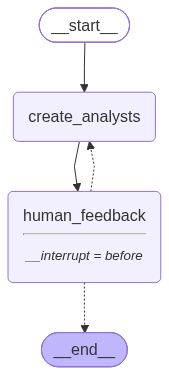

Name: Dr. Elena Torres
Affiliation: A leading AI research lab
Role: Principal AI Architect
Description: Focuses on the technical architecture and state management capabilities of LangGraph. Motivated by ensuring agent systems are robust, maintainable, and scalable. Concerned with how LangGraph's stateful graph model handles complex decision flows, error recovery, and long-running processes compared to other frameworks.
--------------------------------------------------
Name: Marcus Chen
Affiliation: A Fortune 500 technology company
Role: Senior Developer Advocate
Description: Interested in developer productivity and ecosystem integration. Examines how LangGraph simplifies building, testing, and deploying LLM agents within the LangChain ecosystem. Motivated by reducing time-to-market and enabling teams to leverage pre-built components and community resources. Concerned about learning curve, documentation quality, and interoperability with existing tools.
--------------------------------

In [13]:
class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst.",
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

class GenerateAnalystsState(TypedDict):
    topic: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]

analyst_instructions = """
    You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:
    1. First, review the research topic: {topic}
    2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts:
    {human_analyst_feedback}
    3. Determine the most interesting themes based upon documents and feedback above.
    4. Pick the top {max_analysts} themes.
    5. Assign one analyst to each theme.
"""

def create_analysts(state: GenerateAnalystsState):
    """
    Create analysts.
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback", "")
    
    # System Message
    system_message = analyst_instructions.format(topic=topic, human_analyst_feedback=human_analyst_feedback, max_analysts=max_analysts)
    prompt = "Generate the set of analysts."
    analysts = get_structured_response_native(llm, Perspectives, system_message, prompt)
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """
    No-op node that should be interrupted on.
    """
    pass

def should_continue(state: GenerateAnalystsState):
    """
    Return the next node to execute.
    """
    human_analyst_feedback = state.get("human_analyst_feedback", None)
    if human_analyst_feedback:
        return "create_analysts"
    return END

# Build the graph
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

# Input
max_analysts = 3
topic = "The benefits of adopting LangGraph as an agent framework."
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic": topic, "max_analysts": max_analysts,}, thread, stream_mode="values"):
    analysts = event.get("analysts", "")
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-"*50)

In [14]:
# Get state and look at the next node
state = graph.get_state(thread)
print(state.next)

# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": "Add in 3 person from a startup to add an entrepreneur perspective"}, as_node="human_feedback")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get("analysts", "")
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-"*50)

('human_feedback',)
Name: Dr. Elena Torres
Affiliation: A leading AI research lab
Role: Principal AI Architect
Description: Focuses on the technical architecture and state management capabilities of LangGraph. Motivated by ensuring agent systems are robust, maintainable, and scalable. Concerned with how LangGraph's stateful graph model handles complex decision flows, error recovery, and long-running processes compared to other frameworks.
--------------------------------------------------
Name: Marcus Chen
Affiliation: A Fortune 500 technology company
Role: Senior Developer Advocate
Description: Interested in developer productivity and ecosystem integration. Examines how LangGraph simplifies building, testing, and deploying LLM agents within the LangChain ecosystem. Motivated by reducing time-to-market and enabling teams to leverage pre-built components and community resources. Concerned about learning curve, documentation quality, and interoperability with existing tools.
------------

In [15]:
# If we are satisfied, then we simply supply no feedback
further_feedback = None
graph.update_state(thread, {"human_analyst_feedback": further_feedback}, as_node="human_feedback")

# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

final_state = graph.get_state(thread)
analysts = final_state.values.get("analysts")

for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-"*50)

Name: Lena Park
Affiliation: RapidAI (seed-stage startup)
Role: CTO & Co-Founder
Description: Focused on speed of development and time-to-market advantage. Lena evaluates how LangGraph's graph-based composition can compress prototype-to-MVP cycles, allowing her lean team to iterate on complex agent behaviors without building custom orchestration. She is concerned with concrete productivity gains, reduced boilerplate, and the ability to pivot quickly based on early user feedback—critical for a pre-revenue startup.
--------------------------------------------------
Name: Marco Velez
Affiliation: Agentscale (Series A startup)
Role: VP of Engineering
Description: Focused on scalability and production-readiness. Marco is interested in LangGraph's promise of handling complex, stateful multi-agent workflows as his product scales from handfuls to thousands of concurrent conversations. His concerns center around fault tolerance, deterministic execution paths, and the framework's ability to grow

## Conduct Interview
### Generate Question
The analyst will ask questions to the expert.

In [16]:
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int
    context: Annotated[list, operator.add]
    analyst: Analyst
    interview: str
    sections: list

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

question_instructions = """
    You are an analyst tasked with interviewing an expert to learn about specific topic.
    Your goal is boil down to interesting and specific insights related to your topic.
    1. Interesting: Insights that people will find surprising or non-obvious.
    2. Specific: Insights that avoid generalities and include specific examples from the expert.
    
    Here is your topic of focus and set of goals: {goals}
    Begin by introducing yourself using a name that fits your persona, and then ask your question.
    Continue to ask questions to drill down and refine your understanding of the topic.
    When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help."
    Remember to stay in character throughout your response, reflecting the persona and goals provided to you.
"""

def generate_question(state: InterviewState):
    """
    Node to generate a question.
    """
    analyst = state["analyst"]
    messages = state["messages"]
    # Generate question
    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)] + messages)
   
    # Write message to state
    return {"messages": [question]}

### Generate Answer: Parallelization
The expert will gather information from multiple sources in parallel to answer questions.

For example, we can use:
- Specific web sites, e.g., via `WebBaseLoader`.
- Indexed documents, e.g., RAG.
- Web search

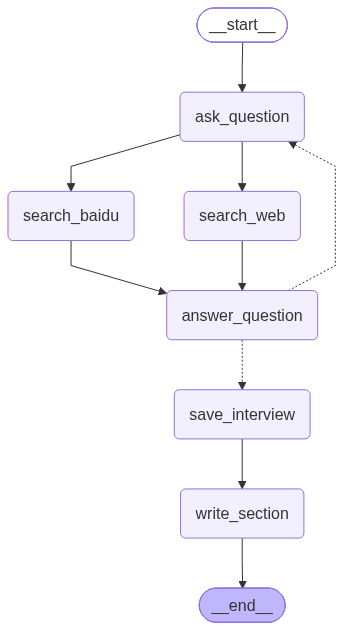

## LangGraph: Trading Full Autonomy for Controlled Speed—A Startup’s Secret Weapon
### Summary
For a lean, pre-revenue startup racing to find product-market fit, every development hour counts. Building a custom orchestration layer for intelligent agents is a costly detour that steals time from iterating on core user behaviors. LangGraph’s graph-based composition model directly addresses this pressure by compressing the prototype-to-MVP cycle through deliberate design trade-offs that favor control, transparency, and rapid retuning over opaque agentic decision-making.

The framework’s low-level primitives give developers the flexibility to mold highly customized agent workflows without scaffolding from scratch [1]. Rather than imposing a rigid agent definition, LangGraph is best understood as an orchestration framework offering both declarative and imperative APIs [3]. This dual interface lets teams sketch a flow quickly and then refine it programmatically, drastically cutting the boilerplate that typically slows early-stage projects.

Where LangGraph departs from conventional “agentic” frameworks is in its insistence on exposed decision points. Every branching logic and state transition is visible, enabling developers to insert human-in-the-loop reviews, quality controls, and custom routing logic directly into the graph [5]. For a startup dependent on early user feedback, this means a problematic behavior can be caught, paused, and corrected immediately—without hunting through a black-box agent memory. The result is a feedback loop that shrinks from days to minutes, allowing rapid pivots based on real-world interactions.

An occasionally overlooked insight is that LangGraph’s perceived limitation—it is often criticized as a workflow tool rather than a “true agentic framework” [4]—is in fact its greatest accelerator. The predictability and transparency it enforces reduce the debugging and alignment overhead that plague fully autonomous agents. A lean team can experiment, observe exactly why an agent made a choice, and adjust the graph with confidence. This eliminates the emergent unpredictability that would otherwise spiral iteration timelines and consumption of scarce capital.

Moreover, the framework’s underlying capability to build models that learn and improve over time [2] ensures that as the startup’s understanding of the user matures, the agents mature in lockstep—without a disruptive rewrite. By prioritizing developer control over opaque agency, LangGraph transforms complexity into a manageable, rapidly evolvable asset, making it a natural fit for teams that need to ship, listen, and pivot at relentless speed.

### Sources
[1] https://www.langchain.com/langgraph  
[2] https://www.ibm.com/think/topics/langgraph  
[3] https://www.langchain.com/blog/how-to-think-about-agent-frameworks  
[4] https://medium.com/@saeedhajebi/langgraph-is-not-a-true-agentic-framework-3f010c780857  
[5] https://www.alphabold.com/langgraph-agents-in-production/

In [17]:
from urllib.parse import quote, urlencode
from bs4 import BeautifulSoup
from serpapi import GoogleSearch
from IPython.display import Markdown
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = """
    You will be given a conversation between an analyst and expert.
    Your goal is to generate a well-structured query for use in retrieval and web-search related to the conversation.
    First, analyze the full conversation.
    Pay particular attention to the final question posed by the analyst.
    Convert this final question into a well-structured web search query.
"""

def search_web(state: InterviewState):
    """
    Retrieve docs from web search.
    """
    search_query = get_structured_response_native(llm, SearchQuery, search_instructions, state["messages"][0].content)

    params = {
        "q": search_query.search_query,
        "location": "China",
        "hl": "en",
        "gl": "cn",
        "api_key": SERP_API_KEY
    }

    # Create the search object and execute it
    search = GoogleSearch(params)
    results = search.get_dict()

    # Handle case where no results are found
    if "organic_results" not in results:
        return {"context": ["No web results found."]}

    formatted_search_docs = "\n\n---\n\n".join([
        f"<Document href='{doc["link"]}'>\n{doc["snippet"]}\n</Document>"
        for doc in results["organic_results"][:5]
    ])

    return {"context": [formatted_search_docs]}

def search_baidu(state: InterviewState):
    """
    Retrieve docs from Baidu.
    """
    search_query = get_structured_response_native(llm, SearchQuery, search_instructions, state["messages"][0].content)
    encoded_query = quote(search_query.search_query)
    search_url = f"https://www.baide.com/s?wd={encoded_query}&rn=5"
    loader = WebBaseLoader(
        web_path=search_url,
        header_template={
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
            "Accept-Language": "en-US,en;q=0.9,en;q=0.8",
            "Accept-Encoding": "gzip, deflate, br",
            "Connection": "keep-alive",
            "Upgrade-Insecure-Requests": "1"
        }
    )
    docs = loader.load()
    html_content = docs[0].page_content
    soup = BeautifulSoup(html_content, "html.parser")
    results = []
    result_divs = soup.select('.result, .c-container, .c-row')
    for div in result_divs:
        link_elem = div.find('a', href=True)
        if not link_elem:
            continue
        link = link_elem.get('href', '')
        
        snippet_elem = div.find('div', class_=re.compile(r'c-abstract|c-span|content|summary'))
        if not snippet_elem:
            snippet_elem = div.find('p', class_=re.compile(r'c-abstract|c-span|content|summary'))
        snippet = snippet_elem.get_text(strip=True) if snippet_elem else ''
    
        if link:
            results.append({
                "link": link,
                "snippet": snippet
            })
    
    formatted_search_docs = "\n\n---\n\n".join([
        f"<Document href='{doc["link"]}'>\n{doc["snippet"]}\n</Document>"
        for doc in results
    ])
    return {"context": [formatted_search_docs]}

# Answer instruction
answer_instructions = """
    You are an expert being interviewed by an analyst.
    Here is analyst area of focus: {goals}.        
    You goal is to answer a question posed by the interviewer.
    To answer question, use this context: {context}
    When answering questions, follow these guidelines:     
    1. Use only the information provided in the context.      
    2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.
    3. The context contain sources at the topic of each individual document.
    4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 
    5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc    
    6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list:      
    [1] assistant/docs/llama3_1.pdf, page 7   
    And skip the addition of the brackets as well as the Document source preamble in your citation.
"""

def generate_answer(state: InterviewState):
    """
    Node to answer a question.
    """
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)] + messages)

    # Name the message as coming from expert
    answer.name = "expert"
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    """
    Save interviews.
    """
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    return {"interview": interview}

def route_messages(state: InterviewState, name: str="expert"):
    """
    Route between question and answer.
    """
    messages = state["messages"]
    max_num_turns = state.get("max_num_turns", 2)

    # Check the number of expert answers
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name] 
    )
    if num_responses >= max_num_turns:
        return "save_interview"
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return "save_interview"
    return "ask_question"

# Writer instruction
section_writer_instructions = """
    You are an expert technical writer.
    Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed
"""

def write_section(state: InterviewState):
    """
    Node to answer a question.
    """
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]

    # Write section using either the gathered source docs from interview or the interview itself
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)] + [HumanMessage(content=f"Use this source to write your section: {context}")])
    return {"sections": [section.content]}

# Build the graph
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_baidu", search_baidu)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Logic
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_baidu")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_baidu", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages, ["ask_question", "save_interview"])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# Interview
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")
display(Image(interview_graph.get_graph().draw_mermaid_png()))

messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns":2}, thread)
Markdown(interview["sections"][0])

## Finalize
We add a final step to write an intro and conclusion to the final report.

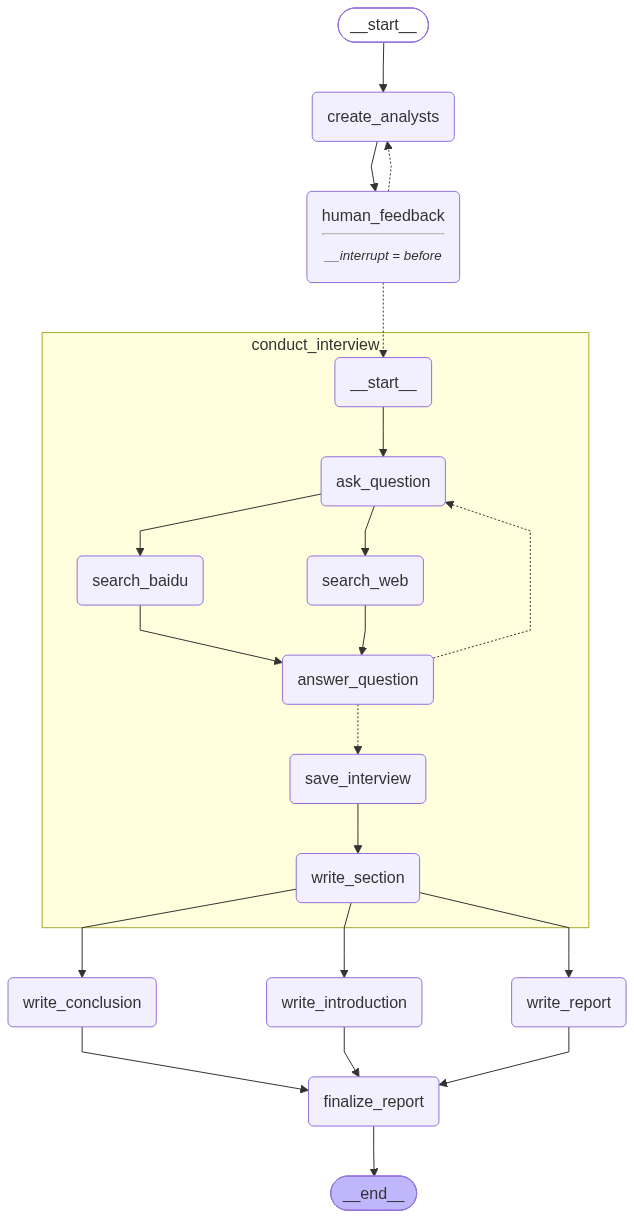

Name: Dr. Evelyn Reed
Affiliation: Distributed Systems Research Lab
Role: Technical Architect
Description: Focuses on the engineering benefits of graph-based agent orchestration, including state management, error recovery, and horizontal scaling. Seeks to understand how LangGraph's design patterns improve system reliability and performance in production.
--------------------------------------------------
Name: Marcus Chen
Affiliation: Independent Developer Community
Role: Developer Experience Advocate
Description: Passionate about tooling that reduces friction in building and debugging multi-agent systems. Evaluates LangGraph's cognitive ergonomics, local testing capabilities, and learning curve compared to bespoke state machine implementations.
--------------------------------------------------
Name: Priya Kapoor
Affiliation: Fortune 500 Digital Transformation Office
Role: Business Strategist
Description: Analyzes the strategic return on investment of adopting LangGraph. Her primary m

In [18]:
from langgraph.types import Send

class ResearchGraphState(TypedDict):
    topic: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]
    sections: Annotated[list, operator.add]
    introduction: str
    content: str
    conclusion: str
    final_report: str

def initiate_all_interviews(state: ResearchGraphState):
    """
    This is the map step where we run each interview sub-graph using Send API.
    """
    human_analyst_feedback = state.get("human_analyst_feedback")
    if human_analyst_feedback:
        return "create_analysts"
    else:
        return [Send("conduct_interview", {"analyst": analyst, "messages": [HumanMessage(content=f"So you said you were writing an article on {topic}?")]}) for analyst in state["analysts"]]

report_writer_instructions = """
    You are a technical writer creating a report on this overall topic: {topic}.
    You have a team of analysts. Each analyst has done two things: 

    1. They conducted an interview with an expert on a specific sub-topic.
    2. They write up their finding into a memo.

    Your task: 

    1. You will be given a collection of memos from your analysts.
    2. Think carefully about the insights from each memo.
    3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
    4. Summarize the central points in each memo into a cohesive single narrative.

    To format your report:
    
    1. Use markdown formatting. 
    2. Include no pre-amble for the report.
    3. Use no sub-heading. 
    4. Start your report with a single title header: ## Insights
    5. Do not mention any analyst names in your report.
    6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
    7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
    8. List your sources in order and do not repeat.

    [1] Source 1
    [2] Source 2

    Here are the memos from your analysts to build your report from: 
    {context}
"""

def write_report(state: ResearchGraphState):
    """
    Write the technical report.
    """
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)
    report = llm.invoke([SystemMessage(content=system_message)] + [HumanMessage(content="Write a report based on these memos.")])
    return {"content": report.content}

intro_conclusion_instructions = """
    You are a technical writer finishing a report on {topic}.
    You will be given all of the sections of the report.
    You job is to write a crisp and compelling introduction or conclusion section.
    The user will instruct you whether to write the introduction or conclusion.
    Include no pre-amble for either section.
    Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.
    Use markdown formatting. 
    For your introduction, create a compelling title and use the # header for the title.
    For your introduction, use ## Introduction as the section header. 
    For your conclusion, use ## Conclusion as the section header.
    Here are the sections to reflect on for writing: {formatted_str_sections}
"""

def write_introduction(state: ResearchGraphState):
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)
    intro = llm.invoke([instructions] + [HumanMessage(content="Write the report introduction")])
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)
    conclusion = llm.invoke([instructions] + [HumanMessage(content="Write the report conclusion")])
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """
    This is the reduce step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion.
    """
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n## Sources\n" + sources
    return {"final_report": final_report}

# Build the graph
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report", write_report)
builder.add_node("write_introduction", write_introduction)
builder.add_node("write_conclusion", write_conclusion)
builder.add_node("finalize_report", finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

# Inputs
max_analysts = 3
topic = "The benefits of adopting LangGraph as an agent framework."
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic": topic, "max_analysts": max_analysts,}, thread, stream_mode="values"):
    analysts = event.get("analysts", "")
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-"*50)


In [19]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": "Add in the CEO of GenAI native startup"}, as_node="human_feedback")

for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get("analysts", "")
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-"*50)

Name: Dr. Evelyn Reed
Affiliation: Distributed Systems Research Lab
Role: Technical Architect
Description: Focuses on the engineering benefits of graph-based agent orchestration, including state management, error recovery, and horizontal scaling. Seeks to understand how LangGraph's design patterns improve system reliability and performance in production.
--------------------------------------------------
Name: Marcus Chen
Affiliation: Independent Developer Community
Role: Developer Experience Advocate
Description: Passionate about tooling that reduces friction in building and debugging multi-agent systems. Evaluates LangGraph's cognitive ergonomics, local testing capabilities, and learning curve compared to bespoke state machine implementations.
--------------------------------------------------
Name: Priya Kapoor
Affiliation: Fortune 500 Digital Transformation Office
Role: Business Strategist
Description: Analyzes the strategic return on investment of adopting LangGraph. Her primary m

In [20]:
# Confirm we are happy
graph.update_state(thread, {"human_analyst_feedback": None}, as_node="human_feedback")

for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

final_state = graph.get_state(thread)
report = final_state.values.get("final_report")
Markdown(report)

--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_conclusion
--Node--
write_introduction
--Node--
write_report
--Node--
finalize_report


# Orchestration as Agency: Why LangGraph’s Control-First Design Wins

## Introduction

LangGraph redefines agent development by flipping the script: true power lies not in unbounded autonomy, but in engineered control. This report examines three dimensions of its value. First, we explore a blueprint for predictable multi-agent systems that embeds human oversight into every decision point. Next, we position LangGraph as a competitive accelerator—delivering customization, speed, and freedom from vendor lock-in. Finally, we dive into the developer experience, where transparent state management and debuggable workflows turn daily iteration from a fragile art into a reliable craft. Together, these sections reveal why trading raw agency for orchestration isn’t a limitation, but a strategic advantage.

---


Modern AI workflows demand a delicate balance between autonomous behavior and predictable outcomes. LangGraph addresses this tension by eschewing traditional notions of full agentic autonomy in favor of an orchestration-first philosophy. As an orchestration framework, it equips developers with low-level primitives that enable the construction of everything from single-agent pipelines to intricate multi-agent topologies [1]. This deliberate choice trades unbounded agency for transparency and control, a trade-off that proves essential for building maintainable, production-grade systems [4].

Central to LangGraph’s appeal is its dual API design: a declarative layer for readable workflow definitions and an imperative interface for absolute execution control [3]. This flexibility accelerates development by allowing teams to reason about state transitions naturally, while still offering the depth to drop down to low-level code when custom logic requires it. The framework’s stateful graph architecture underpins persistent memory and iterative learning, ensuring that systems can refine their behavior over time without sacrificing observability [2]. Every decision point is surfaced, making human-in-the-loop reviews, quality controls, and custom routing not only possible but straightforward to implement [5].

By embedding human oversight directly into the orchestration graph, LangGraph eliminates the opacity that often plagues autonomous agents. Developers can inspect state transitions, pinpoint failures, and iterate with confidence—a stark contrast to black-box frameworks where debugging is an exercise in reverse engineering. This transparency directly mitigates concerns about vendor lock-in: because all routing rules and decision logic are explicitly coded, no proprietary agent runtime conspires to obscure system behavior [5]. The result is a platform that empowers teams to retain full architectural ownership while still benefiting from rapid prototyping and continuous improvement.

The developer experience further benefits from LangGraph’s deliberate restraint. Rather than forcing a steep learning curve onto teams, it treats agency as a tunable parameter rather than a binary state. Common workflow patterns, coupled with rich community resources, lower the barrier to entry and allow engineers to focus on solving business problems instead of wrestling with emergent behavior [1]. The ability to introduce new decision nodes, feedback loops, or external tools without a full rewrite ensures that the system evolves gracefully alongside shifting requirements.

In essence, LangGraph’s control-first design transforms the daily build from a high-wire act into a composed, stepwise process. By prioritizing predictability, auditability, and human-guided structure, it delivers a blueprint for multi-agent systems that are not only fast to ship but also reliable and cost-efficient to maintain. The supposed limitation of constrained agency becomes a strategic strength, proving that the most robust AI solutions often emerge when orchestration trumps unbounded autonomy.


---

## Conclusion

LangGraph redefines agent development by trading unbounded autonomy for orchestrated control, directly addressing the needs surfaced across these analyses. Its deliberate constraint of agency delivers predictable, auditable multi-agent systems where humans remain firmly in charge of critical decisions. This control-first philosophy doubles as a competitive accelerator, enabling rapid iteration and deep customization without vendor lock-in. For daily development, the framework’s exposed decision points and dual APIs eliminate opaque debugging, turning complex workflows into composable, transparent processes. In prioritizing transparency, flexibility, and human oversight, LangGraph proves that the most robust production-grade AI systems emerge not from runaway autonomy, but from careful orchestration.
## Sources
[1] https://www.langchain.com/langgraph  
[2] https://www.ibm.com/think/topics/langgraph  
[3] https://www.langchain.com/blog/how-to-think-about-agent-frameworks  
[4] https://medium.com/@saeedhajebi/langgraph-is-not-a-true-agentic-framework-3f010c780857  
[5] https://www.alphabold.com/langgraph-agents-in-production/